### Coursework Question 1

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import logsumexp

#### Import the data

Import and plot the given dataset:

In [8]:
y = np.genfromtxt("data.csv")

Text(0, 0.5, 'y')

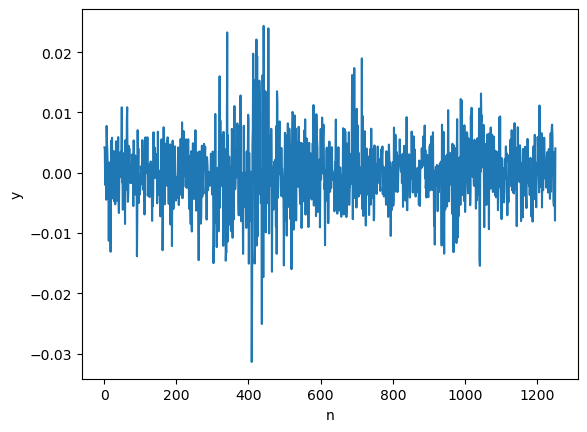

In [9]:
timesteps = np.arange(1,len(y)+1)
plt.plot(timesteps,y)
plt.xlabel("n")
plt.ylabel("y")

#### Run the model

Firstly we will generate a synthetic dataset using the model stated in the question:

In [2]:
def generate_data(T):

    # Generate initial value of x randomly from N(0,1) and set seed for reproducibility
    rng1 = np.random.default_rng(1)
    x0 = stats.norm.rvs(random_state=rng1)

    # Generate values of noise for V and W
    rng2 = np.random.default_rng(2)
    v = stats.norm.rvs(loc=0,scale=np.sqrt(0.1),size=T,random_state=rng2)
    
    rng3 = np.random.default_rng(3)
    w = stats.norm.rvs(loc=0,scale=1,size=T+1,random_state=rng3)

    # Arrays to store hidden state (x) and observations (y)
    x = np.zeros(T+1)
    x[0] = x0
    y = np.zeros(T+1)
    y[0] = 1/20*x0**2 + w[0]

    # Recursively calculate hidden state and observations
    for i in range(1,T+1):
        x[i] = 1/2*x[i-1] + 25*x[i-1]/(1+x[i-1]**2) + 8*np.cos(1.2*i) + v[i-1]
        y[i] = 1/20*x[i]**2 + w[i]

    return x,y

In [3]:
hidden_state,y = generate_data(200)

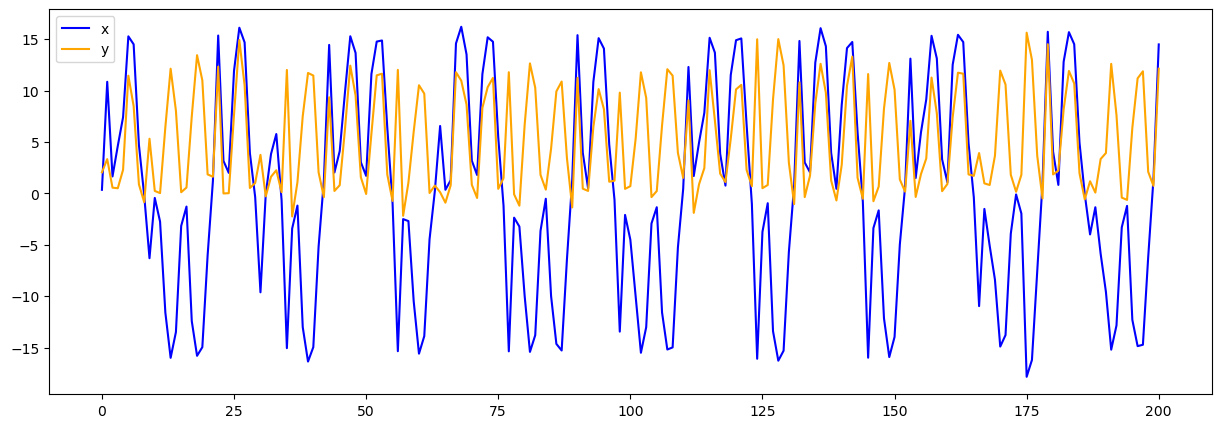

In [4]:
timesteps = np.arange(0,201)
plt.figure(figsize=(15,5))
plt.plot(timesteps,hidden_state,color="blue",label="x")
plt.plot(timesteps,y,color="orange",label="y")
plt.legend()

#### SIR Particle Filter

In this case, $f(x_n|x_{n-1}) = N(\rho x_{n-1}, \sigma^2)$, and $g(y_n|x_n) = N(0, \beta^2 \exp(\frac{x_n}{2})^2)$

Functions for SIR:

In [16]:
def log_f(x,x_prev,rho,sigma2):

    mean = rho*x_prev
    var = sigma2
    
    val = -1/2*np.log(2*np.pi*var) - 1/(2*var)*(x-mean)**2
    return val

In [17]:
def log_g(x,y,beta2):

    mean = 0
    var = beta2*np.exp(x/2)**2
    
    val = -1/2*np.log(2*np.pi*var) - 1/(2*var)*(y-mean)**2
    return val

In [18]:
def prop_mean_var(y,x_prev,rho,sigma2):

    S = sigma2
    m = rho*x_prev

    return m,S

In [19]:
def log_q(x,m,S):

    val = -1/2*np.log(2*np.pi*S) - 1/(2*S)*(x-m)**2
    return val

In [20]:
def resample(omega, X, rng):

    # Number of particles
    N = len(X[:,0])

    # Sample offspring from a multinomial distribution with probabilities equal to weights omega
    copies = stats.multinomial.rvs(N,omega,random_state=rng)

    new_X = np.zeros(X.shape)

    # Make new particles by copying each old particle a number of times equal to 'copies'
    k = 0
    for i in range(N):
        if copies[i]>0:
            for _ in range(copies[i]):
                new_X[k,:] = X[i,:]
                k = k+1

    return new_X

In [32]:
def SIR(y,rho,sigma2,beta2,N):

    # Get the full length of the sequence
    T = len(y)

    # Set array to store the particle history and unnormalised weights at each time step
    X = np.zeros((N,T))
    unnormalised_weights = np.zeros((N,T))

    # TIME 0
    # Sample from initial proposal (N(0,0.1^2))
    rng = np.random.default_rng(seed=0)
    X[:,0] = stats.norm.rvs(loc=0,scale=0.1,size=N,random_state=rng)
        
    # Calculated log unnormalised weights and store them
    log_omega = log_g(X[:,0],y[0],beta2)
    unnormalised_weights[:,0] = log_omega 

    # Normalise weights and resample particles
    max_val = np.max(log_omega)
    omega = np.exp(log_omega-max_val)/np.sum(np.exp(log_omega-max_val))
    X = resample(omega,X,rng)

    # TIME n>0
    for n in range(1,T):
        
        m,S = prop_mean_var(y[n],X[:,n-1],rho,sigma2)
        rng = np.random.default_rng(seed=n)
        X[:,n] = stats.norm.rvs(loc=m,scale=np.sqrt(S),random_state=rng)
        
        log_omega = log_f(X[:,n],X[:,n-1],rho,sigma2) + log_g(X[:,n],y[n],beta2) - log_q(X[:,n],m,S)
        unnormalised_weights[:,0] = log_omega
        
        max_val = np.max(log_omega)
        omega = np.exp(log_omega-max_val)/np.sum(np.exp(log_omega-max_val))
        X = resample(omega,X,rng)

    return unnormalised_weights

Functions for Particle MCMC:

In [22]:
def compute_marginal_likelihood(log_weights):

    N = log_weights.shape[0]
    log_p = logsumexp(log_weights,axis=0) - np.log(N)
    log_marginal_likelihood = np.sum(log_p)

    return log_marginal_likelihood

In [23]:
def log_p(rho,sigma2,beta2):

    # Uniform prior for rho
    log_prho = np.log(1/2)

    # IG(1,1) prior for sigma2
    log_psigma2 = -2*sigma2 - 1/sigma2

    # IG(1,1) prior for beta2
    log_pbeta2 = -2*beta2 - 1/beta2

    # Multiply densities <=> Add log densities
    val = log_prho + log_psigma2 + log_pbeta2

    return val

In [ ]:
def log_q(rho_a, sigma2_a, beta2_a, rho_b, sigma2_b, beta2_b):

    

    return val

In [25]:
def particle_mcmc(y,iters):

    # FIRST ITERATION
    # List to store MCMC Chain
    rho_chain = []
    sigma2_chain = []
    beta2_chain = []
    
    # Sample starting values randomly from the prior
    rng = np.random.default_rng(seed=0)
    rho = stats.uniform.rvs(loc=-1,scale=2,random_state=rng)
    sigma2 = stats.invgamma.rvs(a=1,random_state=rng)
    beta2 = stats.invgamma.rvs(a=1,random_state=rng)

    # Append to mcmc chains
    rho_chain.append(rho)
    sigma2_chain.append(sigma2)
    beta2_chain.append(beta2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights = SIR(y,rho,sigma2,beta2,N=500)

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        new_rho = 
        new_sigma2 = 
        new_beta2 = 

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights = SIR(y,new_rho,new_sigma2,new_beta2,N=500)
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        # Compute Metropolis-Hastings acceptance ratio
        log_ratio = log_marginal_likelihood + log_p(new_rho,new_sigma2,new_beta2) + log_q(rho,sigma2,beta2,new_rho,new_sigma2,new_beta2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_p(rho,sigma2,beta2) - log_q(new_rho,new_sigma2,new_beta2,rho,sigma2,beta2)

        # Accept move with probability given by ratio, else reject
        rng = np.random.default_rng(i)
        if log_ratio <= np.log(stats.uniform.rvs(random_state=rng)):
            rho = new_rho
            sigma2 = new_sigma2
            beta2 = new_beta2

        # Add values to the mcmc chains 
        rho_chain.append(rho)
        sigma2_chain.append(sigma2)
        beta2_chain.append(beta2)

        # Update the previous value of log marginal likelihood
        log_marginal_likelihood_prev = log_marginal_likelihood

        return rho_chain, sigma2_chain, beta2_chain   

In [33]:
log_marginal_likelihood = particle_mcmc(y,iters=1)